Iris データ読み込み
   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6

特徴量:
['sepal length (cm)', 'sepal width (cm)']

クラス:
['setosa' 'versicolor' 'virginica']

train_test_split
X_train: (105, 2)
X_test : (45, 2)

GridSearchCV 開始

最良パラメータ
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 10}

最良CVスコア
0.7619047619047619

予測

Accuracy
0.6

Confusion Matrix
[[13  0  2]
 [ 1 12  2]
 [ 0 13  2]]

Classification Report
              precision    recall  f1-score   support

      setosa       0.93      0.87      0.90        15
  versicolor       0.48      0.80      0.60        15
   virginica       0.33      0.13      0.19        15

    accuracy                           0.60        45
   macro avg       0.58      0.60      0.56        45
weighted avg       0.58      0.60      0.56        45


決定木表示


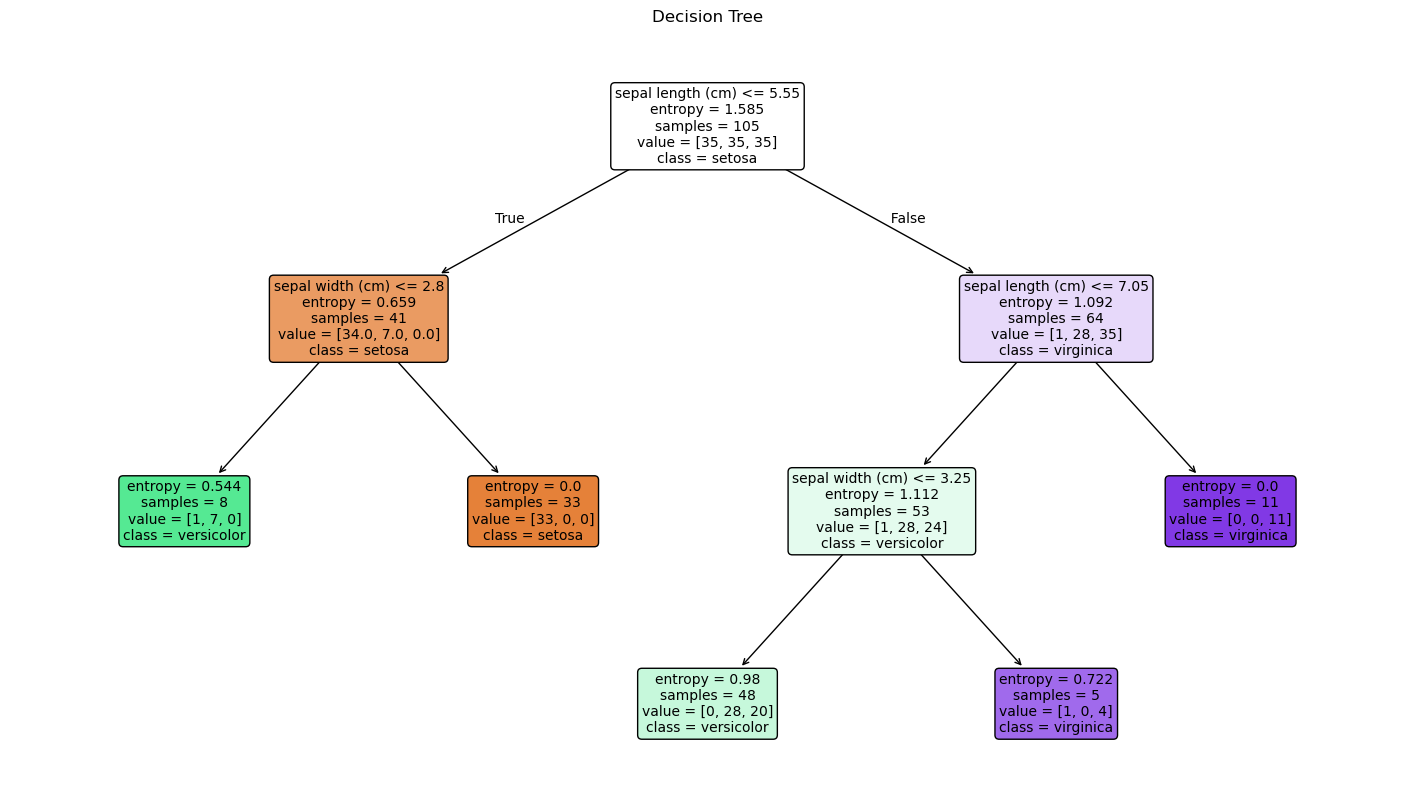


決定境界 描画


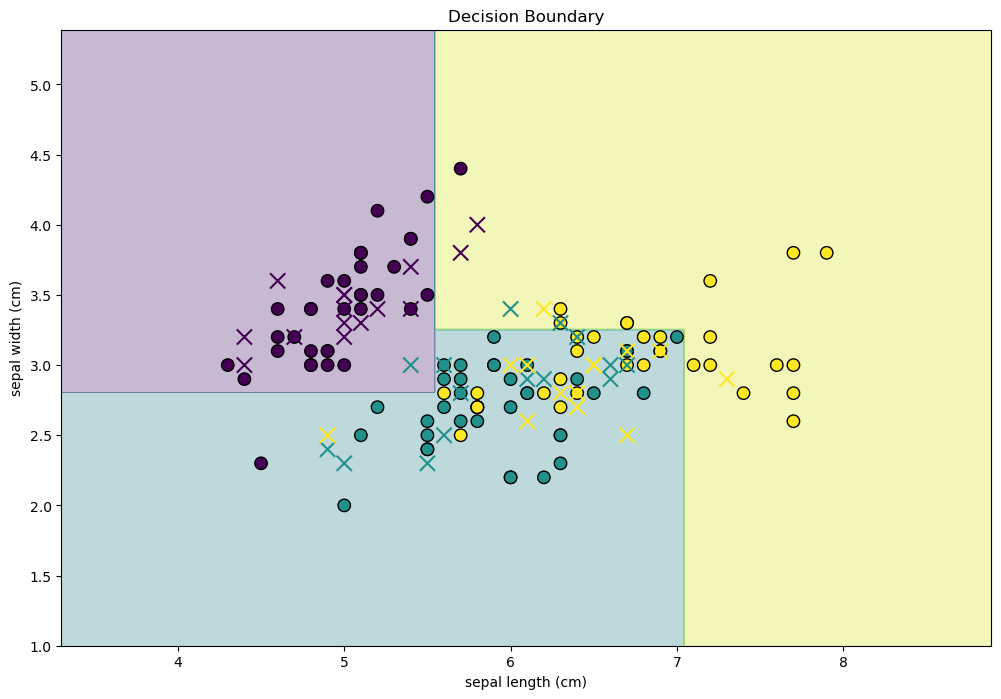


特徴量重要度
             feature  importance
0  sepal length (cm)       0.722
1   sepal width (cm)       0.278


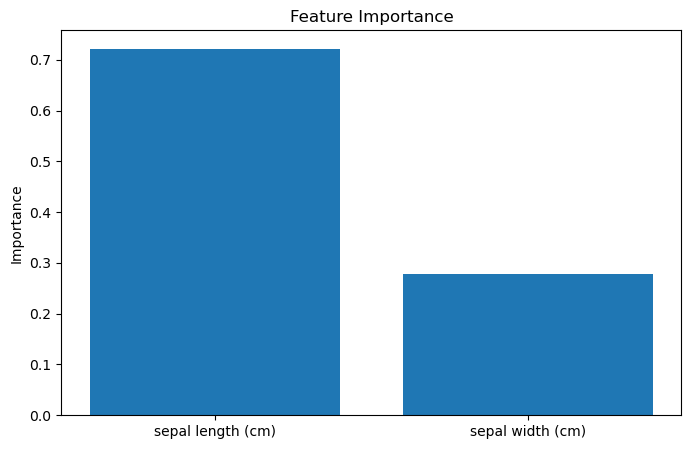


処理完了


In [4]:
# =========================================
# Iris データ + 決定木 + 境界線描画 完全版
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn import tree


# =========================================
# 1. データ読み込み
# =========================================
print("Iris データ読み込み")

iris = load_iris()

# 最初の2特徴量のみ使用
X = iris.data[:, :2]
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names[:2]
)

print(df.head())

print()
print("特徴量:")
print(iris.feature_names[:2])

print()
print("クラス:")
print(iris.target_names)


# =========================================
# 2. train/test 分割
# =========================================
print()
print("train_test_split")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# =========================================
# 3. GridSearchCV
# =========================================
print()
print("GridSearchCV 開始")

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

gs_inst = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gs_inst.fit(X_train, y_train)

print()
print("最良パラメータ")
print(gs_inst.best_params_)

print()
print("最良CVスコア")
print(gs_inst.best_score_)


# =========================================
# 4. テスト予測
# =========================================
print()
print("予測")

y_pred = gs_inst.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print()
print("Accuracy")
print(acc)

print()
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print()
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


# =========================================
# 5. 決定木表示
# =========================================
print()
print("決定木表示")

plt.figure(figsize=(18, 10))

tree.plot_tree(
    gs_inst.best_estimator_,
    feature_names=iris.feature_names[:2],
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree")

plt.show()


# =========================================
# 6. 境界線プロット
# =========================================
print()
print("決定境界 描画")

# 軸範囲
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

# 格子点作成
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# 全格子点を予測
Z = gs_inst.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# =========================================
# 描画
# =========================================
plt.figure(figsize=(12, 8))

# 背景の分類領域
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# 学習データ
scatter = plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k",
    s=80
)

# テストデータ
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    marker="x",
    s=120
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

plt.title("Decision Boundary")

plt.show()


# =========================================
# 7. 特徴量重要度
# =========================================
print()
print("特徴量重要度")

importance_df = pd.DataFrame({
    "feature": iris.feature_names[:2],
    "importance": gs_inst.best_estimator_.feature_importances_
})

print(importance_df)


# =========================================
# 8. 特徴量重要度プロット
# =========================================
plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.show()


# =========================================
# 完了
# =========================================
print()
print("処理完了")